Bring in necessary imports

In [1]:
using Plots, LinearAlgebra, Random, Statistics, DifferentialEquations, Optim, Printf, ForwardDiff
import StochasticDiffEq as SDE

include("src/ProblemInterface.jl")
using .ProblemInterface

# Problem Setup
Consider a problem where there is some "thing" (such as fish, crops, etc) that grows with time that we need to strategically "harvest" to sell for a reward.

If we harvest too much, we'll set us up for failure later. If we harvest too little, we leave performance on the table.

We formulate this as the following optimal control problem:
$$
\max R = \mathbb{E}\left[ \int_{0}^{\infty} e^{- \rho t} x_t \left(1 - e^{- \alpha u_t} \right) dt \right]
$$

subject to the dynamics:
$$
dx_{t} = (r x_t - u_t) dt + \sigma x_t dW_t
$$

where $x$ represents the "thing", $u$ represents our harvesting rate (our control), $r$ represents the growth rate, $\sigma$ represents the volatility associated with the "noise" process (which is where the stochasticity enteres the system), $\rho$ represents the discount rate for the objective, and $\alpha$ represents the sensitivity of the reward to the harvesting rate.

In [2]:
# Define parameters
mutable struct Params
    α::Float64      # Reward sensitivity
    ρ::Float64      # Objective discount rate
    r::Float64      # growth rate
    σ::Float64      # volatility
    u_ctrl::Float64 # control variable (initially set to 0, will be optimized)
end

params = Params(0.5, 0.3, 0.15, 0.1, 0.0)

# Define the SDE dynamics
function drift!(du, u, p, t)
    du[1] = p.r * u[1] - p.u_ctrl
end

function diffusion!(du, u, p, t)
    du[1] = p.σ * u[1]
end

diffusion! (generic function with 1 method)

# Simulate system

## Naive Constant Control Strategy
As a baseline, to get the system working, we consider a naive control strategy that assume harvesting should be constant across the time horizon.

In [3]:
# Define initial condition and time span
u0 = [1.0]
tspan = (0.0, 10.0)
dt = 0.01


function objective(u_val)
    # Extract control from optimization variable
    u_ctrl = u_val[1] # Extract from the array passed by Optim
    p = Params(params.α, params.ρ, params.r, params.σ, u_ctrl)

    # Define the SDE problem
    prob = SDEProblem(drift!, diffusion!, u0, tspan, p)
    
    # Monte Carlo simulation
    N = 500 
    results = map(1:N) do _
        # Simulate the SDE with the current control
        sol = solve(prob, SDE.EM(), dt=dt, adaptive=false)
        
        # Evaluate objective
        xvals = first.(sol.u)
        reward = sum(
            exp.(-p.ρ .* sol.t) .* xvals .*
            (1 .- exp.(-p.α .* u_ctrl))
        ) * dt

        return reward
    end
    
    # Compute the average objective across simulations (negate for minimization)
    return -mean(results)
end

res = optimize(objective, 0.0, 1.0, Brent())
println("Optimal control found: ", Optim.minimizer(res))

Optimal control found: 0.19205360962681664


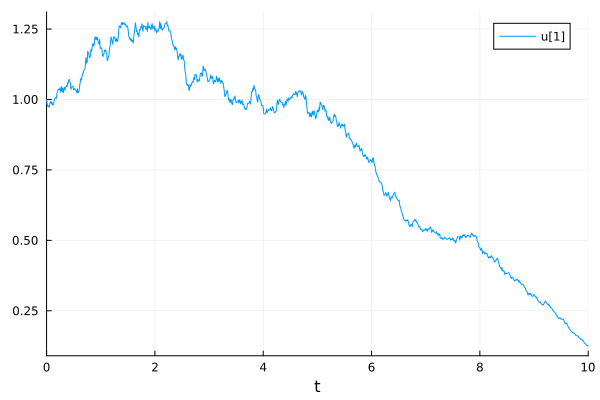

In [4]:
opt_params = Params(params.α, params.ρ, params.r, params.σ, Optim.minimizer(res))
prob = SDEProblem(drift!, diffusion!, u0, tspan, opt_params)
sol = solve(prob, SDE.EM(), dt=0.01)
plot(sol)

# HJB Solving
To find the optimal control, we must satisfy the HJB equation. We derive the HJB equation below.

We know the value function must satisfy:
$$
V(x) = \sup_{u_t} \mathbb{E}_{x} \left[ \int_{0}^{\infty} e^{-\rho t} x_t \left( 1 - e^{- \alpha u_t} \right) dt \right]
$$

and the associated HJB condition is given by:
$$
\rho V(x) = \max_{u} \left\{ x(1-e^{-\alpha u}) + (rx-u)V_{x}(x) + \frac{1}{2} \sigma^2 x^2 V_{xx}(x) \right\}
$$

We can solve for the optimal control by setting up the Hamiltonian:
$$
H(x,u,p) = x\left(1-e^{- \alpha u}\right) + (rx-u)V_{x}(x)
$$

and solving for $u^*$ as follows:
$$
\begin{align*}
\frac{\partial H}{\partial u} &= \alpha x e^{- \alpha u} - V_{x} = 0\\
V_x &= \alpha x e^{\alpha u^*}\\
u^*(x) &= - \frac{1}{\alpha} \ln \left( \frac{V_{x}(x)}{\alpha x} \right)
\end{align*}
$$

Substituting this back into the HJB expression:
$$
\rho V = x - \frac{V_x}{\alpha} + rx V_x + \frac{V_x}{\alpha} \ln \left( \frac{V_x}{\alpha x} \right) + \frac{1}{2} \sigma^2 x^2 V_{xx}
$$

We now explore various methods of satisfying this HJB equation in order to achieve the optimal control.

## Adaptive Dynamic Programming


We provide a basis function to approximate the form of the solution. We choose to use:
$$
V(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3
$$
as our estimated form. ADP seeks to identify the values of theta that best satisfy the HJB condition.

In [5]:
# Basis function for approximation and associated derivatives
function V(x, θ)
    return θ[1] + θ[2]*x + θ[3]*x^2 + θ[4]*x^3
end

function Vx(x, θ)
    return θ[2] + 2θ[3]*x + 3θ[4]*x^2
end

function Vxx(x, θ)
    return 2θ[3] + 6θ[4]*x
end

# Policy derived from the value function approximation
function policy(x, θ, α)
    z = Vx(x, θ)/(α*x)
    z = clamp(z, 1e-8, 0.999)

    return -(1/α)*log(z)
end

# HJB residual function to evaluate the approximation quality
function hjb_residual(x, θ, p)
    u = policy(x, θ, p.α)
    lhs = p.ρ * V(x, θ)
    rhs = x*(1-exp(-p.α*u)) + (p.r*x-u)*Vx(x, θ) + 0.5*p.σ^2*x^2*Vxx(x, θ)

    return lhs - rhs
end

hjb_residual (generic function with 1 method)

Now we sample a representative state space and optimize/solve for the parameters.

In [6]:
# Sample points for training the value function approximation
xtrain = collect(range(0.1, 10.0, length=200))

# Define loss function for optimization
function loss(θ)
    return mean(hjb_residual(x, θ, params)^2 for x in xtrain)
end

# Initial guess for θ
theta_guess = [0.0, 0.1, 0.0, 0.0] # starting with linear approximation

# Optimize the parameters of the value function approximation
res = optimize(loss, theta_guess, BFGS())
theta_opt = Optim.minimizer(res)

4-element Vector{Float64}:
 -0.009990642130169371
  0.028212017527803075
  0.24809865575778933
 -0.007019700177859839

Now we simulate the system with the learned policy

In [7]:
mutable struct ADPParams
    α::Float64
    ρ::Float64
    r::Float64
    σ::Float64
    θ::Vector{Float64}
end

# Define the drift and diffusion functions for the ADP simulation
function drift_adp!(du, u, p, t)
    x = u[1]
    harvest = policy(x, p.θ, p.α)
    du[1] = p.r*x - harvest
    return du
end

function diffusion_adp!(du, u, p, t)
    du[1] = p.σ * u[1]
    return du
end


# Define parameters for simulation
adp_params = ADPParams(params.α, params.ρ, params.r, params.σ, theta_opt)

# Define initial condition and time span for ADP simulation
u0 = [1.0]
tspan = (0.0, 10.0)

# Simulate the system using the derived policy
prob = SDEProblem(drift_adp!, diffusion_adp!, u0, tspan, adp_params)
sol = solve(prob, SDE.EM(), dt=0.01)

retcode: Success
Interpolation: 1st order linear
t: 1001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.060000000000000005
  0.07
  0.08
  0.09
  0.09999999999999999
  0.10999999999999999
  0.11999999999999998
  ⋮
  9.889999999999834
  9.899999999999833
  9.909999999999833
  9.919999999999833
  9.929999999999833
  9.939999999999833
  9.949999999999832
  9.959999999999832
  9.969999999999832
  9.979999999999832
  9.989999999999831
 10.0
u: 1001-element Vector{Vector{Float64}}:
 [1.0]
 [0.9786602105804738]
 [0.9767066490204733]
 [0.9727774249559742]
 [0.9540993677952696]
 [0.9550795265164203]
 [0.953794976518854]
 [0.9602026081205485]
 [0.9554607622049874]
 [0.9533855235927629]
 [0.9447840697277149]
 [0.9372001992562996]
 [0.9540193100016152]
 ⋮
 [2.4615487419335853]
 [2.4489795598796853]
 [2.454453579642905]
 [2.4646985446758074]
 [2.4850597681034037]
 [2.4712121146372477]
 [2.477302538263845]
 [2.477985795070261]
 [2.4728214182039143]
 [2.4607659227176084]
 [2.48

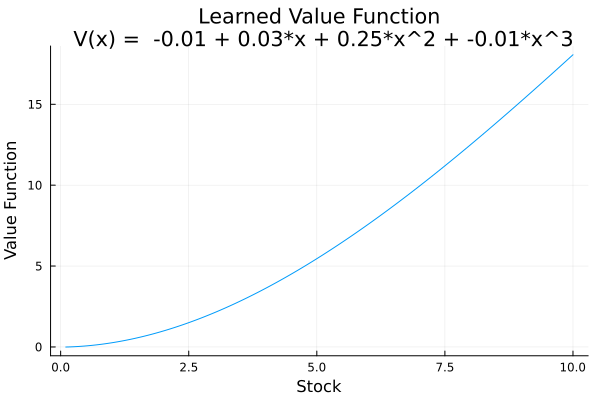

In [8]:
# Plot the learned value function approximation
xvals = collect(range(0.1, 10.0, length=200))
v_vals = [V(x, theta_opt) for x in xvals]
rounded_thetas = round.(theta_opt, digits=2)
plot(xvals, v_vals, 
    title="Learned Value Function\n $V(x) =  $(rounded_thetas[1]) + $(rounded_thetas[2])*x + $(rounded_thetas[3])*x^2 + $(rounded_thetas[4])*x^3",
    xlabel="Stock", ylabel="Value Function", legend=false)

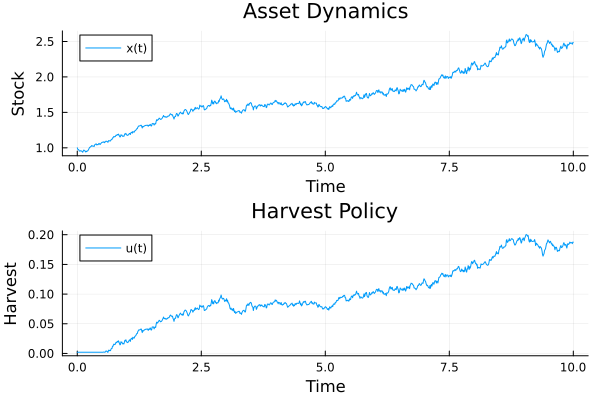

In [9]:
xvals = first.(sol.u)
uvals = [policy(x, theta_opt, adp_params.α) for x in xvals]
adp_asset_plot = plot(sol.t, xvals, title="Asset Dynamics", xlabel="Time", ylabel="Stock", label="x(t)")
adp_harvest_plot = plot(sol.t, uvals, title="Harvest Policy", xlabel="Time", ylabel="Harvest", label="u(t)")
plot(adp_asset_plot, adp_harvest_plot, layout=(2,1))

## Deep Backwards Stochastic Differential Equations (BSDE)

Starting from the value function definition:
$$
V(x) = sup_u E[ ∫₀^∞ e^{−ρt} x_t (1 − e^{−αu_t}) dt ]
$$

and defining:
$$
Y_t = e^{−ρt} V(x_t),
$$

Itô's lemma on Y_t gives (using the HJB to substitute the drift):
$$
dY_t = −e^{−ρt} x_t(1 − e^{−αu*_t}) dt  +  Z_t dW_t        
$$
(BSDE) where the *adjoint process* is:
$$
Z_t = e^{−ρt} V_x(x_t) · σ x_t
$$

Terminal condition:  $Y_T → 0$  (transversality, since ρ > 0 and V bounded).

Strategy:
• Parameterise  Z_t ≈ Znet_θ(t, x_t)  with a neural network
• Parameterise  Y_0 = V(x_0) ≈ Y0net_φ(x_0)  with a second network
• Forward-simulate the BSDE over [0, T] by Euler-Maruyama
• Minimise  E[(Y_T)²]  over θ, φ


In [10]:
using Flux, Statistics, Random, Plots, DifferentialEquations
import StochasticDiffEq as SDE

In [11]:
# Define parameters for the training loop
const r_b = params.r
const σ_b = params.σ
const ρ_b = params.ρ
const α_b = params.α

 
# Derive the optimal control from the value function approximation and adjoint variable
function u_star(Z_t, t, x)
    Vx  = Z_t * exp(ρ_b * t) / (σ_b * x + 1e-7)
    arg = Vx  / (α_b * x   + 1e-7)
    # clamp before log to avoid NaN during early training
    arg = clamp(arg, 1e-7, 1e7)
    u   = -(1 / α_b) * log(arg)
    return clamp(u, zero(u), oftype(u, 20))   # oftype keeps Dual-compatible
end
 
# Broadcast-friendly wrapper
u_star_vec(Z, t, x) = u_star.(Z, t, x)

u_star_vec (generic function with 1 method)

In [12]:
# Define neural network
# Znet: (t, x) → Z_t  — the adjoint process
# Bigger capacity than Y0net because it must represent a function of two vars
#   across the full time horizon.
Znet = Chain(
    Dense(2, 64, tanh),
    Dense(64, 64, tanh),
    Dense(64, 1, softplus)     # ← guarantees Z > 0
)

Y0net = Chain(
    Dense(1, 32, tanh),
    Dense(32, 32, tanh),
    Dense(32, 1, softplus)
)

# Warm-start Znet using the known analytical solution for the adjoint at t=0
x_warm  = collect(range(0.2f0, 10f0, length=512))
Z_adp   = [Vx(x, theta_opt) * σ_b * x for x in x_warm]   # ADP adjoint at t=0

opt_warm = Flux.setup(Flux.Adam(1f-3), Znet)
for _ in 1:2000
    val, g = Flux.withgradient(Znet) do Z
        Z_pred = vec(Z(vcat(zeros(Float32, 1, 512), x_warm')))
        mean((Z_pred .- Float32.(Z_adp)).^2)
    end
    Flux.update!(opt_warm, Znet, g[1])
end
println("Warm-start done. Sample Z at x=1: ", Znet(Float32[0f0, 1f0])[1])


Warm-start done. Sample Z at x=1: 0.058162186


┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(2 => 64, tanh)  # 192 parameters
│   summary(x) = "2×256 Matrix{Float64}"
└ @ Flux C:\Users\kavin\.julia\packages\Flux\hrg9M\src\layers\stateless.jl:60


Epoch  500 | Loss = 0.171771
Epoch 1000 | Loss = 0.048542
Epoch 1500 | Loss = 0.034430
Epoch 2000 | Loss = 0.034232
Epoch 2500 | Loss = 0.031714
Epoch 3000 | Loss = 0.026387
Epoch 3500 | Loss = 0.021398
Epoch 4000 | Loss = 0.017512
Epoch 4500 | Loss = 0.021883
Epoch 5000 | Loss = 0.012413


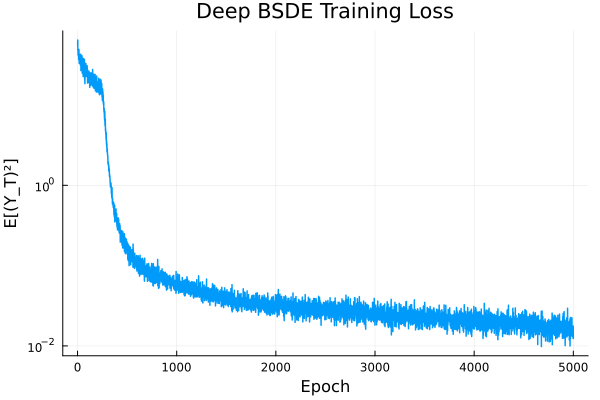

In [13]:
# Simulation Loop
 
function bsde_loss(Znet, Y0net;
                   N_batch = 256,
                   N_steps = 50,
                   T       = 8.0f0,
                   x0_lo   = 0.5f0,
                   x0_hi   = 12.0f0)    # ← was 5.0, widened to cover dynamics

    dt  = T / N_steps
    sdt = sqrt(dt)

    x0 = rand(Float32, N_batch) .* (x0_hi - x0_lo) .+ x0_lo
    Y  = vec(Y0net(x0'))
    x  = copy(x0)

    for n in 0:(N_steps - 1)
        t    = Float32(n) * dt
        tx   = vcat(fill(t, 1, N_batch), x')
        Z    = vec(Znet(tx))
        u    = u_star.(Z, t, x)
        dW   = randn(Float32, N_batch) .* sdt
        f    = exp(-ρ_b * t) .* x .* (1f0 .- exp.(-α_b .* u))
        Y    = Y .- f .* dt .+ Z .* dW
        x    = x .+ (r_b .* x .- u) .* dt .+ σ_b .* x .* dW
        x    = max.(x, 1f-4)
    end

    return mean(Y .^ 2)
end

# Training Loop
Random.seed!(42)
opt_state = Flux.setup(
    Flux.OptimiserChain(Flux.ClipGrad(1.0f0), Flux.Adam(3f-4)),
    (Znet, Y0net)
)

losses = Float64[]
for epoch in 1:5000
    val, grads = Flux.withgradient(
        (Z, Y0) -> bsde_loss(Z, Y0; N_batch=256, N_steps=50),
        Znet, Y0net
    )
    Flux.update!(opt_state, (Znet, Y0net), grads)
    push!(losses, val)
    epoch % 500 == 0 && @printf "Epoch %4d | Loss = %.6f\n" epoch val
end

plot(losses, yscale=:log10,
     xlabel="Epoch", ylabel="E[(Y_T)²]",
     title="Deep BSDE Training Loss", legend=false, lw=1.5)




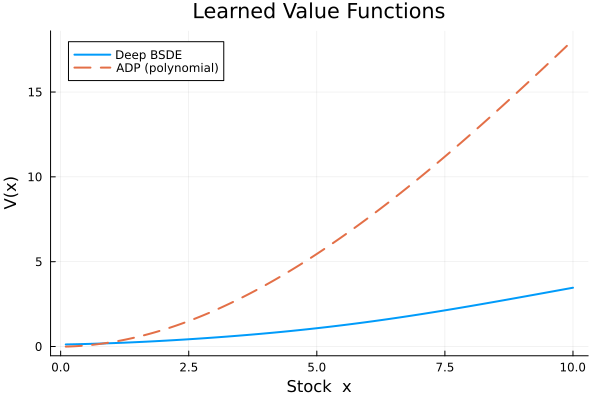

In [14]:
xplot = collect(range(0.1f0, 10f0, length=300))
V_bsde = [Y0net(Float32[x])[1] for x in xplot]
 
# Compare with ADP result (theta_opt must be in scope from earlier cell)
V_adp  = [V(x, theta_opt) for x in xplot]
 
plot(xplot, V_bsde, label="Deep BSDE", lw=2)
plot!(xplot, V_adp,  label="ADP (polynomial)", lw=2, ls=:dash)
xlabel!("Stock  x"); ylabel!("V(x)")
title!("Learned Value Functions")


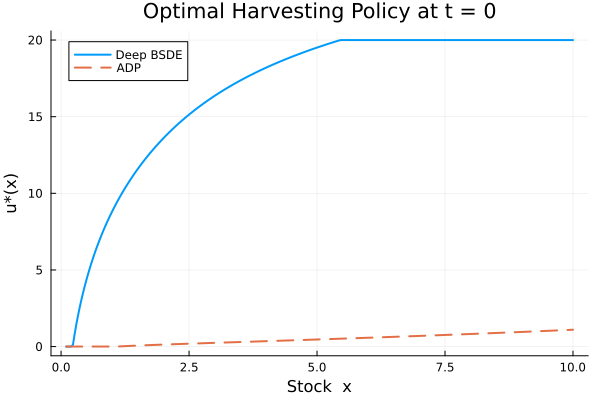

In [15]:
u_bsde_vals = [u_star(Znet(Float32[0f0, x])[1], 0f0, x) for x in xplot]
u_adp_vals  = [policy(x, theta_opt, 0.5) for x in xplot]
 
plot(xplot, u_bsde_vals, label="Deep BSDE", lw=2)
plot!(xplot, u_adp_vals,  label="ADP",       lw=2, ls=:dash)
xlabel!("Stock  x"); ylabel!("u*(x)")
title!("Optimal Harvesting Policy at t = 0")


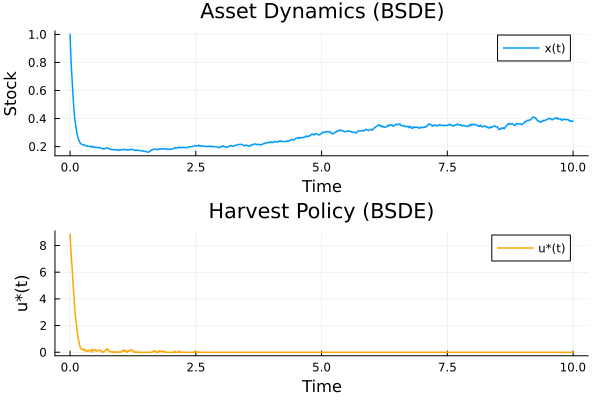

In [16]:
mutable struct BSDEParams
    α::Float64; ρ::Float64; r::Float64; σ::Float64
end
 
function drift_bsde!(du, u_state, p, t)
    x = Float32(u_state[1])
    Z = Znet(Float32[Float32(t), x])[1]
    harvest = u_star(Z, Float32(t), x)
    du[1] = p.r * u_state[1] - harvest
end
 
function diffusion_bsde!(du, u_state, p, t)
    du[1] = p.σ * u_state[1]
end
 
bsde_p   = BSDEParams(params.α, params.ρ, params.r, params.σ)
u0_bsde  = [1.0]
tspan_b  = (0.0, 10.0)
 
prob_bsde = SDEProblem(drift_bsde!, diffusion_bsde!, u0_bsde, tspan_b, bsde_p)
sol_bsde  = solve(prob_bsde, SDE.EM(), dt=0.01)
 
x_sim = first.(sol_bsde.u)
u_sim = [u_star(Znet(Float32[Float32(t), Float32(x)])[1], Float32(t), Float32(x))
         for (t, x) in zip(sol_bsde.t, x_sim)]
 
p1 = plot(sol_bsde.t, x_sim, title="Asset Dynamics (BSDE)",
          xlabel="Time", ylabel="Stock", label="x(t)", lw=1.5)
p2 = plot(sol_bsde.t, u_sim, title="Harvest Policy (BSDE)",
          xlabel="Time", ylabel="u*(t)", label="u*(t)", lw=1.5, color=:orange)
plot(p1, p2, layout=(2,1))


## Physics Informed Neural Network (PINN)

Loss: 9.994444841523267
Loss: 9.521797653880341
Loss: 9.309878600953292
Loss: 9.180540144266773
Loss: 9.958975646535688
Loss: 9.427401828982376
Loss: 9.08793569267954
Loss: 8.771376724550827
Loss: 9.588578532473786
Loss: 9.964838470259757
Loss: 9.240235606785497
Loss: 9.393247375934015
Loss: 9.610769456722258
Loss: 9.396618787181902
Loss: 9.50194650211528
Loss: 9.377676140087914
Loss: 9.525321908931517
Loss: 9.237560290928712
Loss: 9.117864064609766
Loss: 9.135169748057187
Loss: 9.382934622205006
Loss: 9.841197651365151
Loss: 9.349280693040507
Loss: 9.237307673135387
Loss: 9.099149722089807
Loss: 8.864915042784396
Loss: 9.448626420149619
Loss: 9.526378983794949
Loss: 9.304682789389974
Loss: 9.985328558495386
Loss: 9.295610696861466
Loss: 9.548426315460425
Loss: 9.861249196426757
Loss: 9.332732537917472
Loss: 9.333759290809192
Loss: 9.286842226663184
Loss: 9.535371131142488
Loss: 10.196038903347205
Loss: 9.31563425269259
Loss: 8.994815095315667
Loss: 8.766454833359372
Loss: 10.058015842

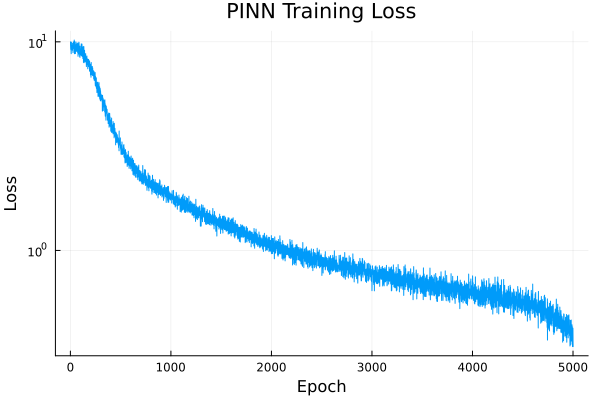

In [17]:
using NeuralPDE, ModelingToolkit, Optimization, OptimizationOptimisers
using Lux, LuxCUDA, ComponentArrays, Random, Symbolics, IntervalSets
using Flux # Required for gpu()

# 1. Improved soft-clamp
function safe_log_arg(val, ϵ=1e-6)
    return ϵ + (val - ϵ) * (tanh((val - ϵ) * 100) * 0.5 + 0.5)
end

function solve_hjb_pinn(params)
    r_val, σ_val, ρ_val, α_val = params.r, params.σ, params.ρ, params.α
    x_min, x_max = 0.10, 5.00 # T_max is completely removed

    loss_history = Float64[]

    # 1. Eliminate time from parameters and variables
    @parameters x
    @variables V(..)
    Dx, Dxx = Differential(x), Differential(x)^2
    V_x = Dx(V(x))

    # 2. Update the first-order necessary condition (FOC) for stationary case
    arg = V_x / (α_val * x)  # exp(-ρ*t) is dropped because t = 0
    u_star = -(1.0 / α_val) * log(safe_log_arg(arg))

    # 3. HJB Equation: replace Dt(V) with -ρ_val * V(x)
    eq = -ρ_val * V(x) + x * (1 - exp(-α_val * u_star)) + 
         V_x * (r_val * x - u_star) + 0.5 * σ_val^2 * x^2 * Dxx(V(x)) ~ 0.0

    # 4. Remove time domain and terminal boundary condition
    domains = [x ∈ Interval(x_min, x_max)]
    bcs = [V(x_min) ~ 0.0, Dx(V(x_max)) ~ 1.0] # at t=0, exp(-ρ*t) = 1.0
    
    @named pde_system = PDESystem(eq, bcs, domains, [x], [V(x)])

    # 5. Change Neural Network input layer size from 2 to 1 (only takes x now)
    inner_size = 32
    chain = Lux.Chain(
        Lux.Dense(1, inner_size, Lux.tanh), # <-- CHANGED FROM 2 TO 1
        Lux.Dense(inner_size, inner_size, Lux.tanh),
        Lux.Dense(inner_size, 1, Lux.identity) 
    )

    rng = Random.default_rng()
    ps, st = Lux.setup(rng, chain)
    ps = ComponentArray(ps) .* 0.01 
    ps_gpu = ps |> Lux.f32 |> gpu

    strategy = StochasticTraining(500)
    discretization = PhysicsInformedNN(chain, strategy, init_params = ps_gpu)
    prob = discretize(pde_system, discretization)

    opt = OptimizationOptimisers.Adam(1e-4)
    callback = function (p, l)
        println("Loss: $l")
        push!(loss_history, l)
        return false
    end

    res = Optimization.solve(prob, opt, callback = callback, maxiters = 5000)
    return res, discretization, loss_history
end

# Run the stationary training
res, discretization, loss_history = solve_hjb_pinn(params)
plot(loss_history, yscale=:log10, xlabel="Epoch", ylabel="Loss", title="PINN Training Loss", legend=false)

In [18]:
mutable struct PINNParams
    α::Float64
    ρ::Float64
    r::Float64
    σ::Float64
    weights
end

# The 'phi' function takes (coords, weights) and returns the NN prediction
phi = discretization.phi

# Function to compute the optimal policy from the learned value function
function get_optimal_policy(x_val, p::PINNParams)
    x = Float64(x_val)
    actual_weights = p.weights 
    
    # Pass a 1D array containing only x to the network's learned representation
    V_func(x_in) = first(discretization.phi([x_in], actual_weights))
    
    Vx_val = ForwardDiff.derivative(V_func, x)
    
    denom = p.α * x
    arg = Vx_val / (denom + 1e-12)
    arg_safe = clamp(arg, 1e-7, 1e7)
    u = -(1.0 / p.α) * log(arg_safe)
    
    return max(u, 0.0)
end

function drift_pinn!(du, u_state, p, t)
    x = u_state[1]
    u = get_optimal_policy(x, p)
    # FIX: Use p.r instead of the global r_val
    du[1] = p.r * x - u 
end

function diffusion_pinn!(du, u_state, p, t)
    x = u_state[1]
    # FIX: Use p.σ instead of the global σ_val
    du[1] = p.σ * x
end

diffusion_pinn! (generic function with 1 method)

┌ Warning: Performing scalar indexing on task Task (runnable, started) @0x000002234a6ba2c0.
│ Invocation of getindex resulted in scalar indexing of a GPU array.
│ This is typically caused by calling an iterating implementation of a method.
│ Such implementations *do not* execute on the GPU, but very slowly on the CPU,
│ and therefore should be avoided.
│ 
│ If you want to allow scalar iteration, use `allowscalar` or `@allowscalar`
│ to enable scalar iteration globally or for the operations in question.
└ @ GPUArraysCore C:\Users\kavin\.julia\packages\GPUArraysCore\aNaXo\src\GPUArraysCore.jl:145


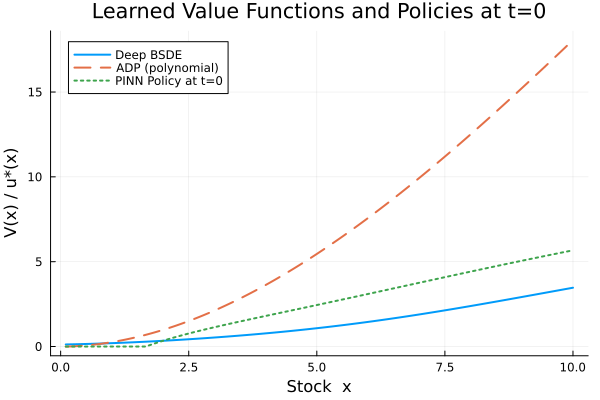

In [19]:
pinn_res_params = PINNParams(params.α, params.ρ, params.r, params.σ, res.u)

plot(xplot, V_bsde, label="Deep BSDE", lw=2)
plot!(xplot, V_adp,  label="ADP (polynomial)", lw=2, ls=:dash)
plot!(xplot, [get_optimal_policy(x, pinn_res_params) for x in xplot], label="PINN Policy at t=0", lw=2, ls=:dot)
xlabel!("Stock  x"); ylabel!("V(x) / u*(x)")
title!("Learned Value Functions and Policies at t=0")

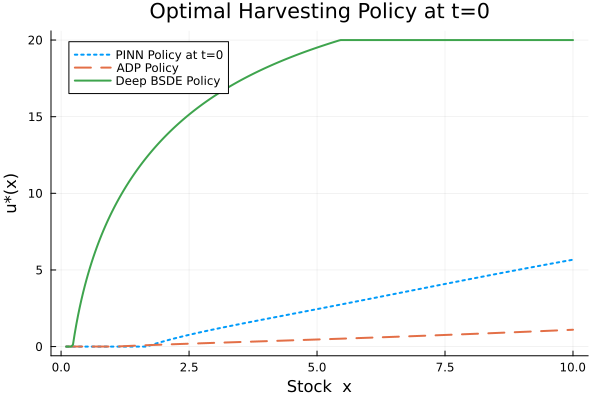

In [20]:
u_pinn_vals = [get_optimal_policy(x, pinn_res_params) for x in xplot]
plot(xplot, u_pinn_vals, label="PINN Policy at t=0", lw=2, ls=:dot)
plot!(xplot, u_adp_vals,  label="ADP Policy", lw=2, ls=:dash)
plot!(xplot, u_bsde_vals, label="Deep BSDE Policy", lw=2, ls=:solid)
xlabel!("Stock  x"); ylabel!("u*(x)")
title!("Optimal Harvesting Policy at t=0")

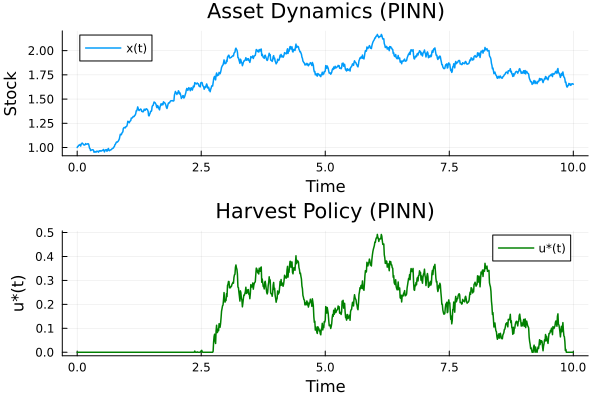

In [21]:
# 3. Instantiate and Simulate
# Make sure `params` is available from your earlier notebook cells
pinn_p = PINNParams(params.α, params.ρ, params.r, params.σ, res.u)
u0_pinn = [1.0]
tspan_pinn = (0.0, 10.0)

prob_pinn = SDEProblem(drift_pinn!, diffusion_pinn!, u0_pinn, tspan_pinn, pinn_p)
sol_pinn = solve(prob_pinn, SDE.EM(), dt=0.01)

# 4. Extract and Plot
x_sim_pinn = first.(sol_pinn.u)

# FIX: Pass `pinn_p` instead of `res.u` to match the function signature
u_sim_pinn = [get_optimal_policy(x, pinn_p) for (t, x) in zip(sol_pinn.t, x_sim_pinn)]

p1 = plot(sol_pinn.t, x_sim_pinn, title="Asset Dynamics (PINN)",
          xlabel="Time", ylabel="Stock", label="x(t)", lw=1.5)
p2 = plot(sol_pinn.t, u_sim_pinn, title="Harvest Policy (PINN)",
          xlabel="Time", ylabel="u*(t)", label="u*(t)", lw=1.5, color=:green)

plot(p1, p2, layout=(2,1))

# Comparing the results

In [22]:
# Unified Policy Wrappers
 
# Naive: constant control stored in opt_params (set before `res` was overwritten)
naive_policy(t, x) = opt_params.u_ctrl
 
# ADP: stationary, so t is ignored
adp_policy(t, x) = clamp(Float64(policy(x, theta_opt, params.α)), 0.0, Inf)

# BSDE: time-dependent adjoint network
function bsde_policy(t, x)
    Z = Znet(Float32[Float32(t), Float32(x)])[1]
    u = u_star(Z, Float32(t), Float32(x))
    return clamp(Float64(u), 0.0, Inf)
end
 
# PINN: uses existing get_optimal_policy (already handles ForwardDiff through phi)
pinn_policy(t, x) = clamp(Float64(get_optimal_policy(x, pinn_p)), 0.0, Inf)

pinn_policy (generic function with 1 method)

In [23]:
 # ---------------------------------------------------------------
# Monte Carlo reward evaluator
# ---------------------------------------------------------------
# Re-simulates the SDE from scratch for each trial — the skeleton
# was accidentally calling the same fixed trajectory N times.
# Uses Threads.@threads for speed (julia --threads auto).
 
function mc_reward(policy_fn;
                   N    = 400,       # number of independent trials
                   x0   = 1.0,
                   T    = 10.0,
                   dt   = 0.01,
                   p    = params)
    α, ρ, r, σ = p.α, p.ρ, p.r, p.σ
    rewards = zeros(N)
 
    Threads.@threads for i in 1:N
        x = x0
        R = 0.0
        t = 0.0
        while t < T - dt/2
            u   = max(policy_fn(t, x), 0.0)
            R  += exp(-ρ * t) * x * (1.0 - exp(-α * u)) * dt
            dW  = sqrt(dt) * randn()
            x   = x + (r*x - u)*dt + σ*x*dW
            x   = max(x, 1e-8)     # keep asset positive
            t  += dt
        end
        rewards[i] = R
    end
 
    μ  = mean(rewards)
    se = std(rewards) / sqrt(N)    # standard error of the mean
    return μ, se
end
 


mc_reward (generic function with 1 method)

In [24]:
# ---------------------------------------------------------------
# HJB residual functions
# ---------------------------------------------------------------
# All methods are evaluated on the same test grid at t = 0 using
# the stationary HJB:  ρV(x) = H(x, V_x, V_xx)

xtest = collect(range(0.5, 7.0, length=80))

# ADP — analytic derivatives, already defined in notebook
adp_hjb_vec = [abs(hjb_residual(x, theta_opt, params)) for x in xtest]

# BSDE — V(x) ≈ Y0net(x); differentiate with ForwardDiff
# Completely clean: no type limits, no ForwardDiff.value, no Float32 casts.
# Julia's type promotion system handles the Dual arithmetic automatically.
function V_bsde_scalar(x)
    return Y0net([x])[1]
end

function hjb_res_bsde(x::Float64)
    Vx_val  = ForwardDiff.derivative(V_bsde_scalar, x)
    Vxx_val = ForwardDiff.derivative(x_ -> ForwardDiff.derivative(V_bsde_scalar, x_), x)
    
    # recover u* from V_x  (same FONC as ADP)
    z = clamp(Vx_val / (params.α * x + 1e-8), 1e-8, 0.999)
    u = max(-(1/params.α) * log(z), 0.0)
    
    lhs = params.ρ * V_bsde_scalar(x)
    rhs = x*(1-exp(-params.α*u)) + (params.r*x - u)*Vx_val + 0.5*params.σ^2*x^2*Vxx_val
    return lhs - rhs
end

bsde_hjb_vec = [abs(hjb_res_bsde(x)) for x in xtest]

# PINN — V(x) ≈ phi([0,x], weights); differentiate with ForwardDiff
function hjb_res_pinn(x::Float64)
    actual_weights = pinn_p.weights
    
    function Vfn(x_)
        return first(discretization.phi([x_], actual_weights))
    end
    
    Vx_val  = ForwardDiff.derivative(Vfn, x)
    Vxx_val = ForwardDiff.derivative(x_ -> ForwardDiff.derivative(Vfn, x_), x)
    
    z = clamp(Vx_val / (params.α * x + 1e-8), 1e-8, 0.999)
    u = max(-(1/params.α) * log(z), 0.0)
    
    lhs = params.ρ * Vfn(x)
    rhs = x*(1-exp(-params.α*u)) + (params.r*x - u)*Vx_val + 0.5*params.σ^2*x^2*Vxx_val
    return lhs - rhs
end

pinn_hjb_vec = [abs(hjb_res_pinn(x)) for x in xtest]

80-element Vector{Float64}:
 0.037054053743953784
 0.046087333709536465
 0.055125514139828996
 0.0641708582014071
 0.07322605413879112
 0.08229398506271676
 0.09137781866612595
 0.10048097854729646
 0.10960725619516104
 0.11876063426254801
 0.12794546464432335
 0.1371663931910811
 0.14642820968532497
 ⋮
 1.9882786550469393
 2.064975953053442
 2.1426083363494692
 2.221146473420969
 2.3005607739647207
 2.380820881158571
 2.461897164462444
 2.5437600641176465
 2.6263794328141232
 2.709725733943186
 2.7937698060600518
 2.8784824808630276

In [25]:
 # ---------------------------------------------------------------
# Run all evaluations
# ---------------------------------------------------------------
println("Running Monte Carlo (N=400, threaded)…")
@time begin
    naive_μ, naive_se = mc_reward(naive_policy)
    adp_μ,   adp_se   = mc_reward(adp_policy)
    bsde_μ,  bsde_se  = mc_reward(bsde_policy)
    pinn_μ,  pinn_se  = mc_reward(pinn_policy)
end
 
adp_hjb  = mean(adp_hjb_vec)
bsde_hjb = mean(bsde_hjb_vec)
pinn_hjb = mean(pinn_hjb_vec)
 


Running Monte Carlo (N=400, threaded)…


┌ Warning: Performing scalar indexing on task Task (runnable, started) @0x00000226b0e78100.
│ Invocation of getindex resulted in scalar indexing of a GPU array.
│ This is typically caused by calling an iterating implementation of a method.
│ Such implementations *do not* execute on the GPU, but very slowly on the CPU,
│ and therefore should be avoided.
│ 
│ If you want to allow scalar iteration, use `allowscalar` or `@allowscalar`
│ to enable scalar iteration globally or for the operations in question.
└ @ GPUArraysCore C:\Users\kavin\.julia\packages\GPUArraysCore\aNaXo\src\GPUArraysCore.jl:145


 66.984478 seconds (275.07 M allocations: 7.573 GiB, 6.60% gc time, 11295 lock conflicts, 0.47% compilation time: 1% of which was recompilation)


0.7885899436350661

In [26]:
# ---------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------
println()
println("╔══════════════════════════════════════════════════════════════════╗")
println("║                    Strategy Comparison                          ║")
println("╠══════════════════════════════════════════════════════════════════╣")
@printf "║  %-20s  %11s  %8s  %18s  ║\n" "Method" "Mean Reward" "± 1.96·SE" "Mean |HJB Resid|"
println("╠══════════════════════════════════════════════════════════════════╣")
@printf "║  %-20s  %11.4f  %8.4f  %18s  ║\n" "Naive (const. u)"  naive_μ 1.96*naive_se "—"
@printf "║  %-20s  %11.4f  %8.4f  %18.4f  ║\n" "ADP (polynomial)"  adp_μ  1.96*adp_se  adp_hjb
@printf "║  %-20s  %11.4f  %8.4f  %18.4f  ║\n" "Deep BSDE"         bsde_μ 1.96*bsde_se bsde_hjb
@printf "║  %-20s  %11.4f  %8.4f  %18.4f  ║\n" "PINN"              pinn_μ 1.96*pinn_se pinn_hjb
println("╚══════════════════════════════════════════════════════════════════╝")
println("  ± column is 95% confidence interval on the mean.")
println("  HJB residual: mean|ρV(x) − H(x,V_x,V_xx)| over x ∈ [0.5, 7]")
 



╔══════════════════════════════════════════════════════════════════╗
║                    Strategy Comparison                          ║
╠══════════════════════════════════════════════════════════════════╣
║  Method                Mean Reward  ± 1.96·SE    Mean |HJB Resid|  ║
╠══════════════════════════════════════════════════════════════════╣
║  Naive (const. u)           0.2373    0.0046                   —  ║
║  ADP (polynomial)           0.1614    0.0082              0.0009  ║
║  Deep BSDE                  0.0877    0.0003              2.1210  ║
║  PINN                       0.2021    0.0106              0.7886  ║
╚══════════════════════════════════════════════════════════════════╝
  ± column is 95% confidence interval on the mean.
  HJB residual: mean|ρV(x) − H(x,V_x,V_xx)| over x ∈ [0.5, 7]


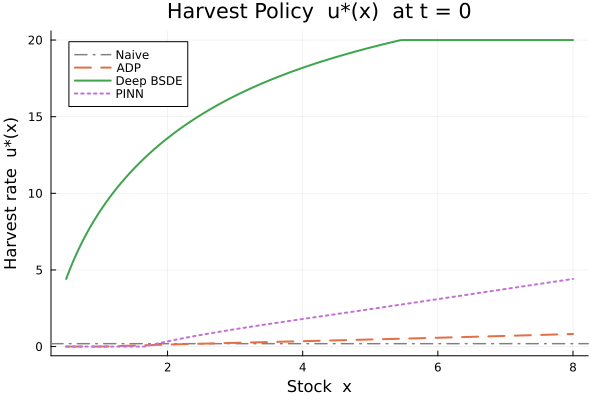

In [27]:
# ---------------------------------------------------------------
# Comparison plots
# ---------------------------------------------------------------
xplot_c = collect(range(0.5, 8.0, length=250))
 
# ── A: Policy comparison ────────────────────────────────────────
p_pol = plot(
    title    = "Harvest Policy  u*(x)  at t = 0",
    xlabel   = "Stock  x",
    ylabel   = "Harvest rate  u*(x)",
    legend   = :topleft,
    lw       = 2
)
hline!(p_pol, [opt_params.u_ctrl],
       label="Naive", lw=1.5, ls=:dashdot, color=:grey)
plot!(p_pol, xplot_c, adp_policy.(0.0, xplot_c),
      label="ADP",       lw=2, ls=:dash)
plot!(p_pol, xplot_c, bsde_policy.(0.0, xplot_c),
      label="Deep BSDE", lw=2, ls=:solid)
plot!(p_pol, xplot_c, pinn_policy.(0.0, xplot_c),
      label="PINN",      lw=2, ls=:dot)


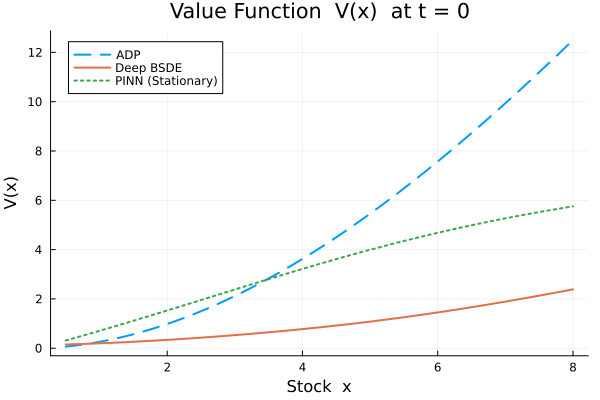

In [28]:

# ── B: Value function comparison ────────────────────────────────
p_val = plot(
    title   = "Value Function  V(x)  at t = 0",
    xlabel  = "Stock  x",
    ylabel  = "V(x)",
    legend  = :topleft,
    lw      = 2
)
plot!(p_val, xplot_c, [V(x, theta_opt) for x in xplot_c],
      label="ADP",      lw=2, ls=:dash)
plot!(p_val, xplot_c, [V_bsde_scalar(x) for x in xplot_c],
      label="Deep BSDE", lw=2, ls=:solid)
plot!(p_val, xplot_c,
      [Float64(first(discretization.phi([x], pinn_p.weights))) for x in xplot_c],
      label="PINN (Stationary)", lw=2, ls=:dot)
 


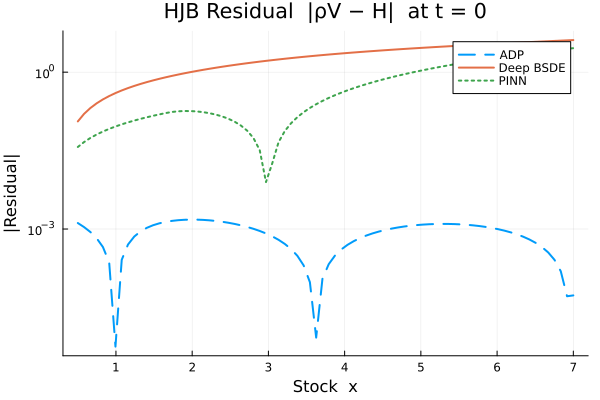

In [29]:
# ── C: HJB residual comparison ──────────────────────────────────
p_hjb = plot(
    title   = "HJB Residual  |ρV − H|  at t = 0",
    xlabel  = "Stock  x",
    ylabel  = "|Residual|",
    legend  = :topright,
    lw      = 2,
    yscale  = :log10
)
plot!(p_hjb, xtest, adp_hjb_vec,  label="ADP",       lw=2, ls=:dash)
plot!(p_hjb, xtest, bsde_hjb_vec, label="Deep BSDE", lw=2, ls=:solid)
plot!(p_hjb, xtest, pinn_hjb_vec, label="PINN",      lw=2, ls=:dot)
 


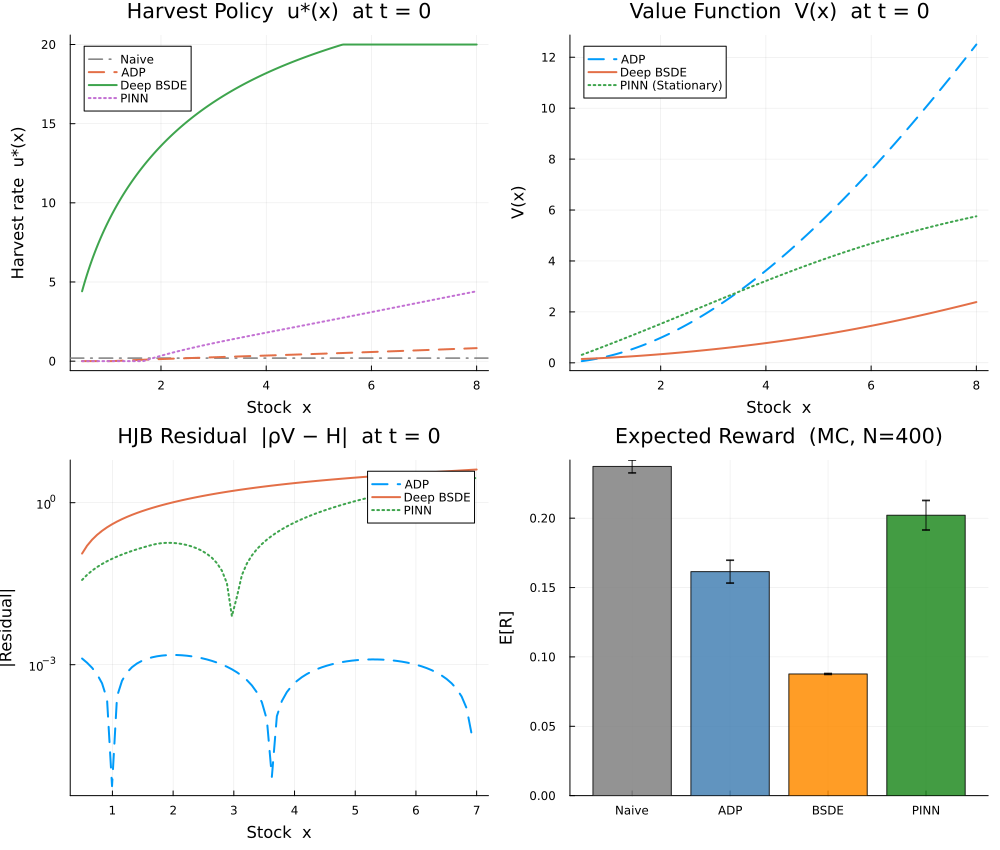

In [30]:
# ── D: Mean reward bar chart with 95% CI ────────────────────────
p_bar = bar(
    ["Naive", "ADP", "BSDE", "PINN"],
    [naive_μ, adp_μ, bsde_μ, pinn_μ],
    yerr   = 1.96 .* [naive_se, adp_se, bsde_se, pinn_se],
    title  = "Expected Reward  (MC, N=400)",
    ylabel = "E[R]",
    legend = false,
    color  = [:grey, :steelblue, :darkorange, :forestgreen],
    alpha  = 0.85
)
 
plot(p_pol, p_val, p_hjb, p_bar, layout=(2, 2), size=(1000, 850))
savefig("figures/asset_harvesting_strat_comparison.png")
plot!()